## CODEX PDAC — StarDist prediction visualization

Counterpart of `CODEX_hcc/Pred_statistic_visual_hcc_all.ipynb`.

1. Load `Clinical_info` for annotated PDAC cores (278).
2. Plot **pooled StarDist ROC** for L2 / L12 / L1.
3. Compare per-core **macro AUROC** across **coverslip** and **SAMPLE_LABEL**.

Shared helpers: `Hist2Pheno_pkg/uni_label_cv_helpers.py`. Clinical loaders: `CODEX_pdac/s1167_plot.py`.


In [1]:
## Setup (CODEX PDAC)
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import sys
import warnings
import logging
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("ome_zarr").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
CODE_DIR = REPO / "code"
PKG_DIR = CODE_DIR / "Hist2Pheno_pkg"
PDAC_CODE_DIR = CODE_DIR / "CODEX_pdac"

for _p in (PKG_DIR, PDAC_CODE_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

PAN_ORGAN = "codex_pdac"
DATA_ROOT = REPO / "data" / "CODEX" / "HCC" / "Michael_data_transfer" / "s1167"
STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial_pdac" / "stardist"
OUT_DIR = DATA_ROOT / "result_all_spatial_pdac" / "clinical_viz_pdac"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("pan_organ:", PAN_ORGAN)


DATA_ROOT: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167
OUT_DIR  : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/clinical_viz_pdac
pan_organ: codex_pdac


## Load clinical information

`raw_metadata_updated.xlsx` sheet `Clinical_info`, `cohort='PDAC'`, annotated cores only.
Demo ACQ: `Charvill-94_c001_v001_r001_reg001`.


In [2]:
import importlib
import s1167_plot
importlib.reload(s1167_plot)
from s1167_plot import load_s1167_clinical_info

clinical = load_s1167_clinical_info(cohort="PDAC", annotated_only=True)


Clinical rows: 278 (cohort=PDAC)


,ACQUISITION_ID,coverslip,SAMPLE_LABEL,SAMPLE_ID,tissue_type
0,Charvill-94_c001_v001_r001_reg002,c001,TA-237,NaN,Pancreas TMA
1,Charvill-94_c001_v001_r001_reg003,c001,TA-237,NaN,Pancreas TMA
2,Charvill-94_c001_v001_r001_reg012,c001,TA-237,NaN,Pancreas TMA
3,Charvill-94_c001_v001_r001_reg014,c001,TA-237,NaN,Pancreas TMA
4,Charvill-94_c001_v001_r001_reg026,c001,TA-237,NaN,Pancreas TMA
5,Charvill-94_c001_v001_r001_reg029,c001,TA-237,NaN,Pancreas TMA
6,Charvill-94_c001_v001_r001_reg037,c001,TA-237,NaN,Pancreas TMA
7,Charvill-94_c001_v001_r001_reg047,c001,TA-237,NaN,Pancreas TMA
8,Charvill-94_c001_v001_r001_reg058,c001,TA-237,NaN,Pancreas TMA
9,Charvill-94_c001_v001_r001_reg065,c001,TA-237,NaN,Pancreas TMA



coverslip


coverslip
c001    148
c003    130
Name: count, dtype: int64


SAMPLE_LABEL


SAMPLE_LABEL
TA-237    148
TA-256    130
Name: count, dtype: int64

## Pooled StarDist ROC (annotated PDAC cores)

Symlink the cores present in `clinical`, then plot pooled OvR ROC for `l2` / `l12` / `l1`.


Linked 278/278 StarDist sample dirs under /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/clinical_viz_pdac/_tmp_selected_stardist

=== L2 | discovering validation_external_stardist_matched_AUROC.csv ===
  Charvill-94_c001_v001_r001_reg001: 5,981 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg002: 4,736 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg003: 4,047 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg004: 3,620 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg005: 8,904 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg006: 4,777 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg007: 5,837 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg008: 4,189 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg009: 7,030 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg010: 5,721 cells, 11 local classes
  Charvill-94_c001_v001_r001_reg011: 6,856 cells, 11 local classes
  Ch

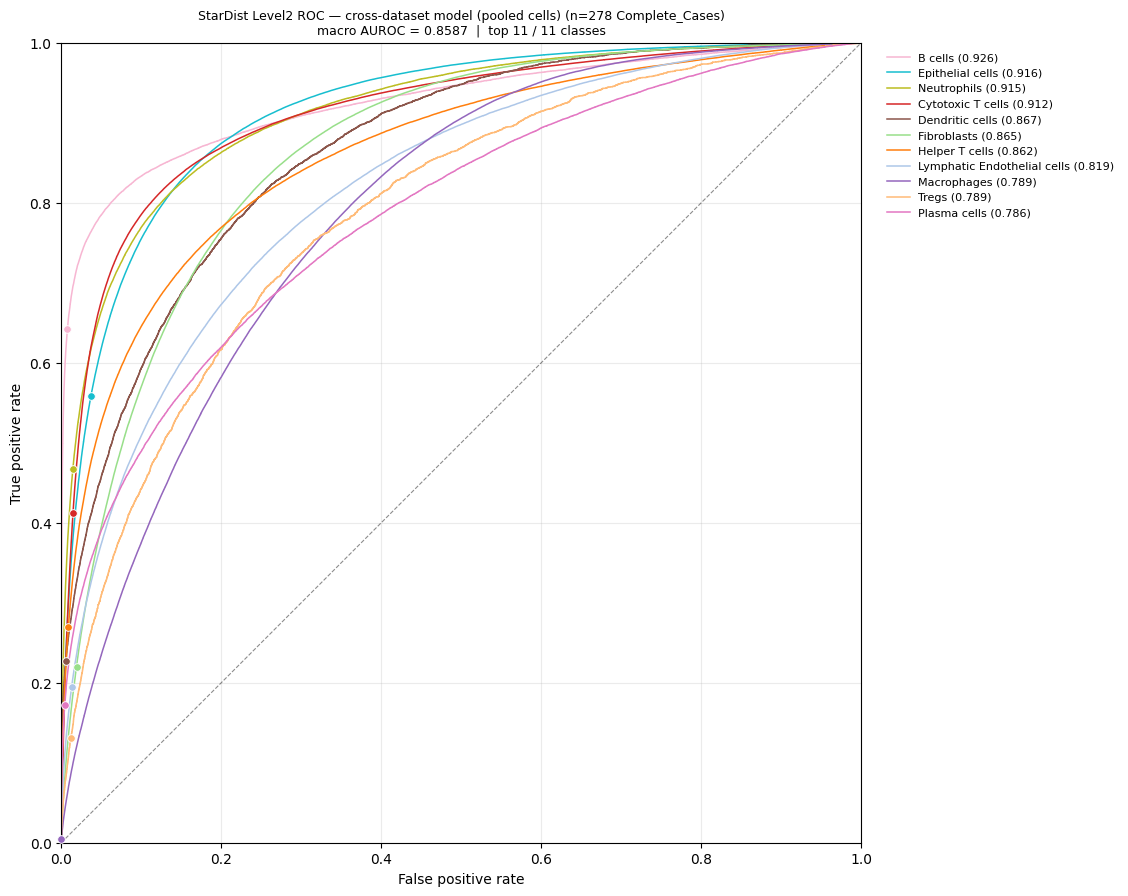

Pooled macro AUROC (L2): 0.8587

=== L12 | discovering validation_external_stardist_matched_AUROC_level12.csv ===
  Charvill-94_c001_v001_r001_reg001: 5,981 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg002: 4,736 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg003: 4,047 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg004: 3,620 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg005: 8,904 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg006: 4,777 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg007: 5,837 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg008: 4,189 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg009: 7,030 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg010: 5,721 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg011: 6,856 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg012: 4,508 cells, 6 local classes
  Charvill-94_c001_v001_r001_reg013: 4,635 cells, 6 local classes
  Charvill-94_c001_v001_r001

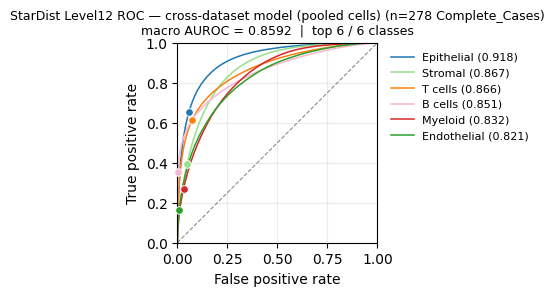

Pooled macro AUROC (L12): 0.8592

=== L1 | discovering validation_external_stardist_matched_AUROC_level1.csv ===
  Charvill-94_c001_v001_r001_reg001: 5,981 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg002: 4,736 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg003: 4,047 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg004: 3,620 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg005: 8,904 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg006: 4,777 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg007: 5,837 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg008: 4,189 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg009: 7,030 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg010: 5,721 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg011: 6,856 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg012: 4,508 cells, 4 local classes
  Charvill-94_c001_v001_r001_reg013: 4,635 cells, 4 local classes
  Charvill-94_c001_v001_r001_

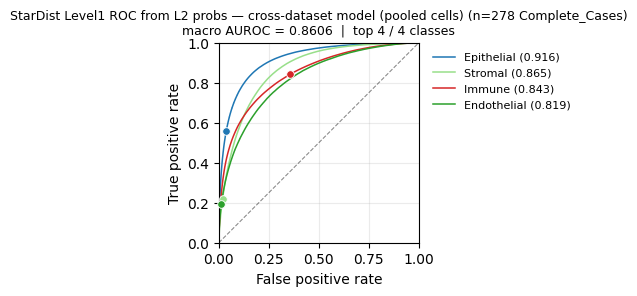

Pooled macro AUROC (L1): 0.8606


In [3]:
import importlib
import uni_label_cv_helpers as uni_nb
import s1167_plot

importlib.reload(uni_nb)
importlib.reload(s1167_plot)
from s1167_plot import PDAC_STARDIST_MACRO_AUROC_TIERS
from uni_label_cv_helpers import plot_pooled_stardist_tier_rocs, symlink_stardist_sample_dirs

filtered_root = symlink_stardist_sample_dirs(
    STARDIST_RESULT_ROOT,
    clinical["ACQUISITION_ID"],
    OUT_DIR / "_tmp_selected_stardist",
)

pooled_roc = plot_pooled_stardist_tier_rocs(
    filtered_root,
    OUT_DIR,
    PDAC_STARDIST_MACRO_AUROC_TIERS,
    layout="pooled_stardist",
    pan_organ=PAN_ORGAN,
    figsize={"l12": (2.0, 2.0), "l1": (2.0, 2.0)},
)


## StarDist macro AUROC vs clinical groups

Per-core macro AUROC across **coverslip** and **SAMPLE_LABEL**.

- `method="rank"`: Mann–Whitney U (2 groups) or Kruskal–Wallis (3+)
- `method="parametric"`: Welch t-test / one-way ANOVA



=== L2 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,macro_auc_l2,rank,Mann-Whitney U,0.211591,10456.0,2,"[c001, c003]","[0.7954407493812082, 0.7862460843816508]","[0.7954407493812082, 0.7862460843816508]",0.674502
1,SAMPLE_LABEL,macro_auc_l2,rank,Mann-Whitney U,0.211591,10456.0,2,"[TA-237, TA-256]","[0.7954407493812082, 0.7862460843816508]","[0.7954407493812082, 0.7862460843816508]",0.674502


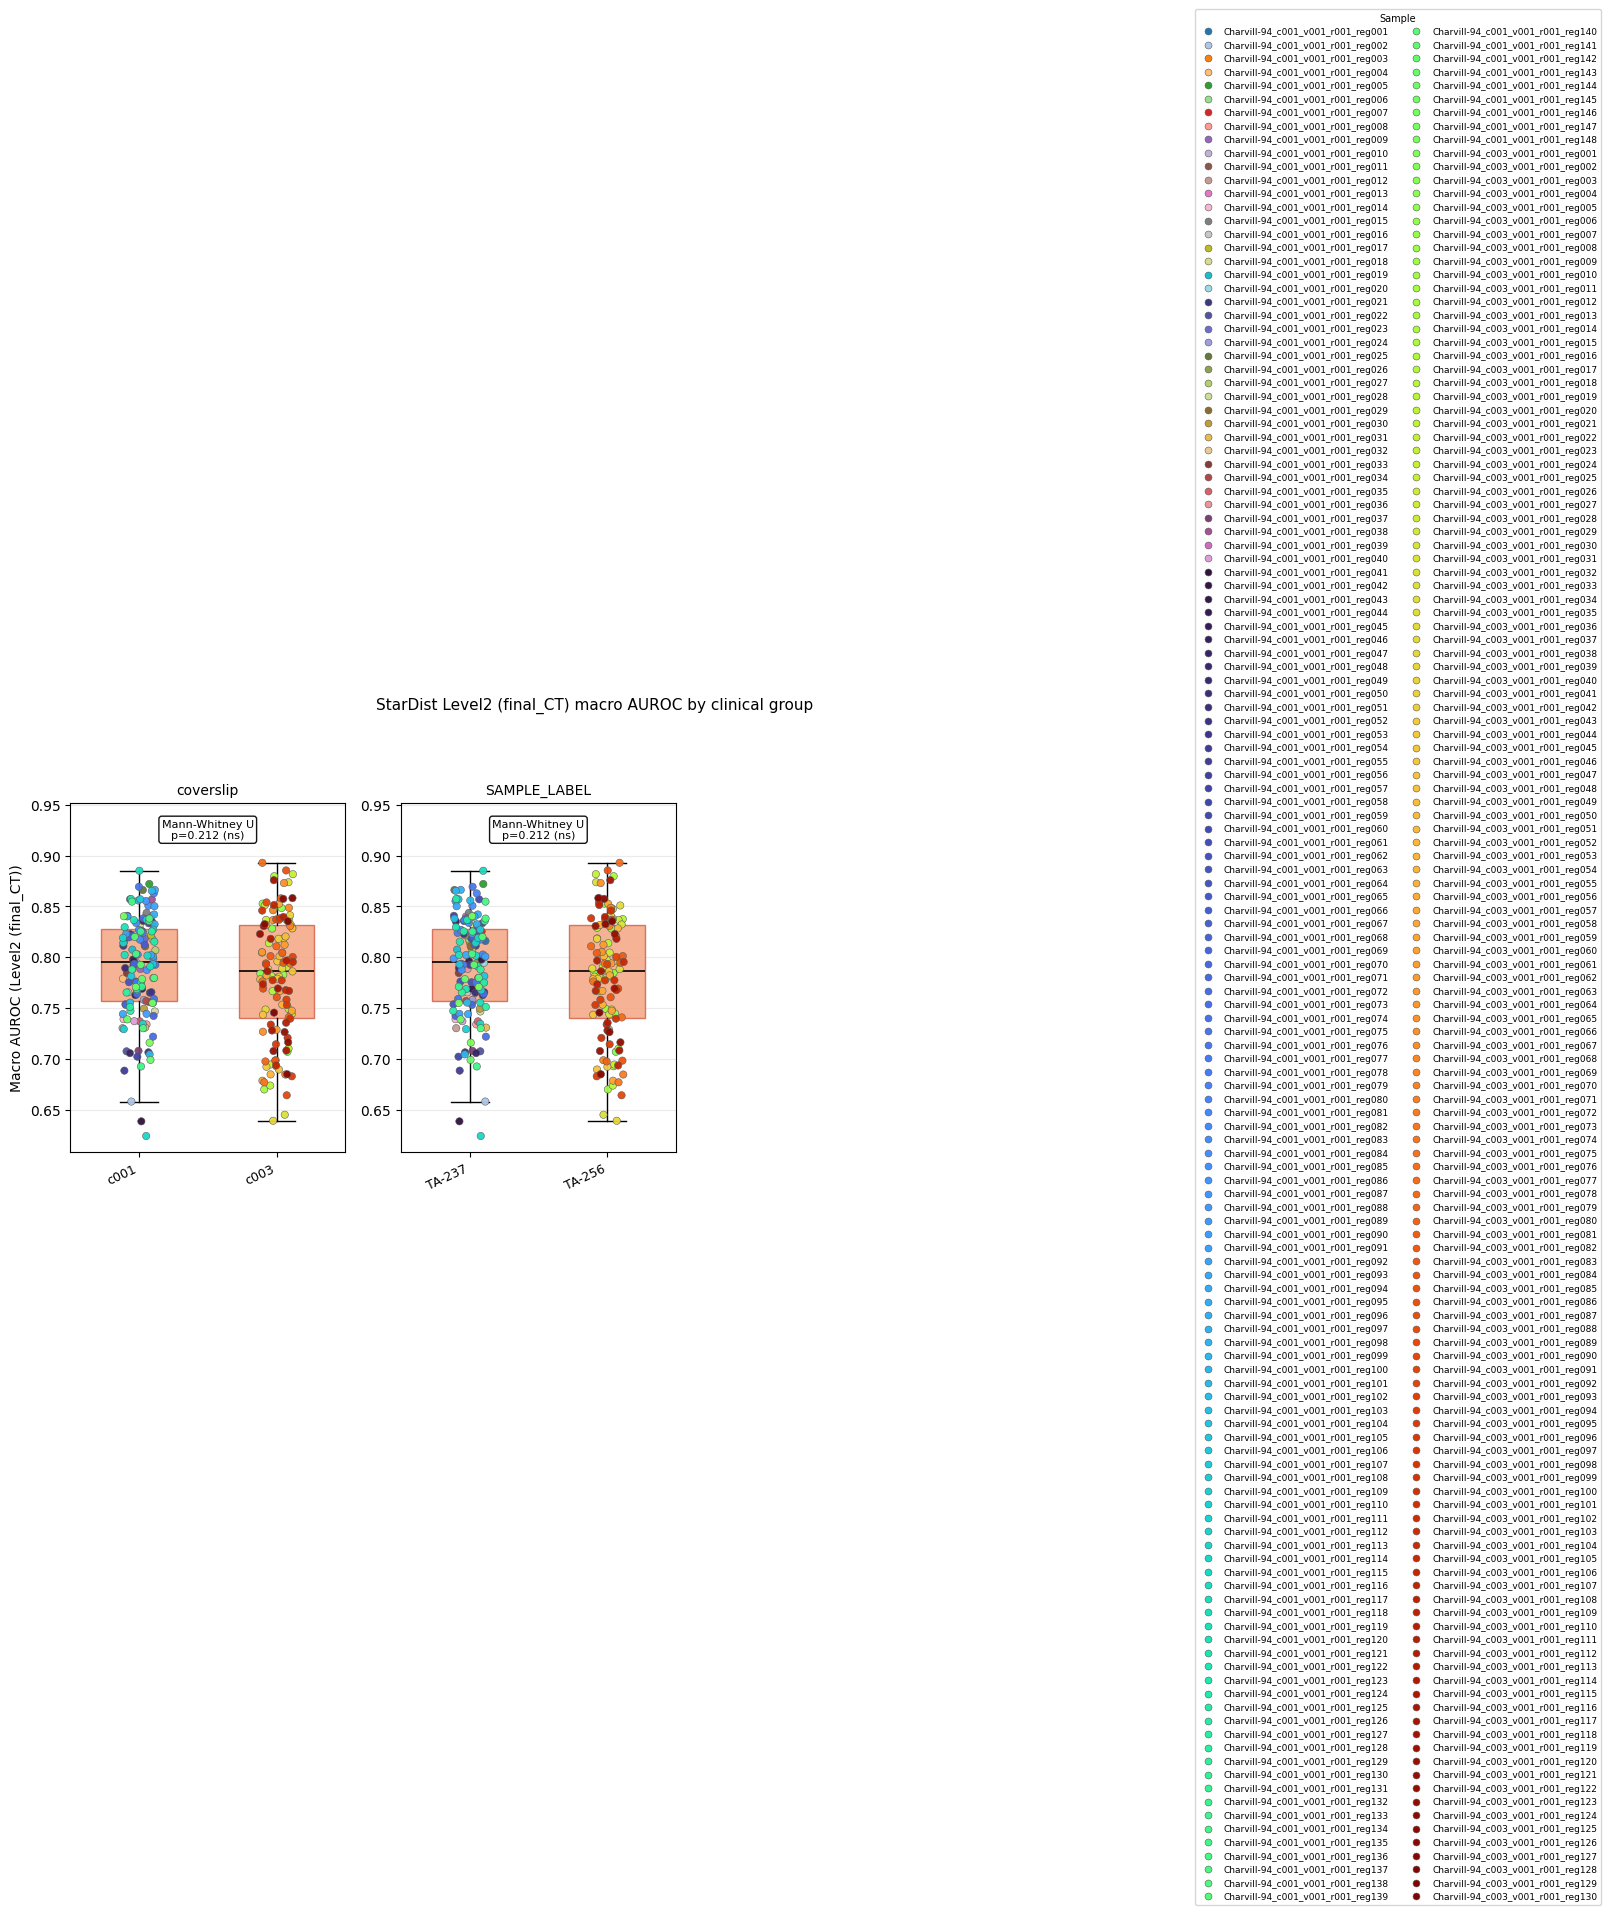


=== L12 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,macro_auc_l12,rank,Mann-Whitney U,0.000299,12039.0,2,"[c001, c003]","[0.8295212716408724, 0.8087347462848493]","[0.8295212716408724, 0.8087347462848493]",3.524103
1,SAMPLE_LABEL,macro_auc_l12,rank,Mann-Whitney U,0.000299,12039.0,2,"[TA-237, TA-256]","[0.8295212716408724, 0.8087347462848493]","[0.8295212716408724, 0.8087347462848493]",3.524103


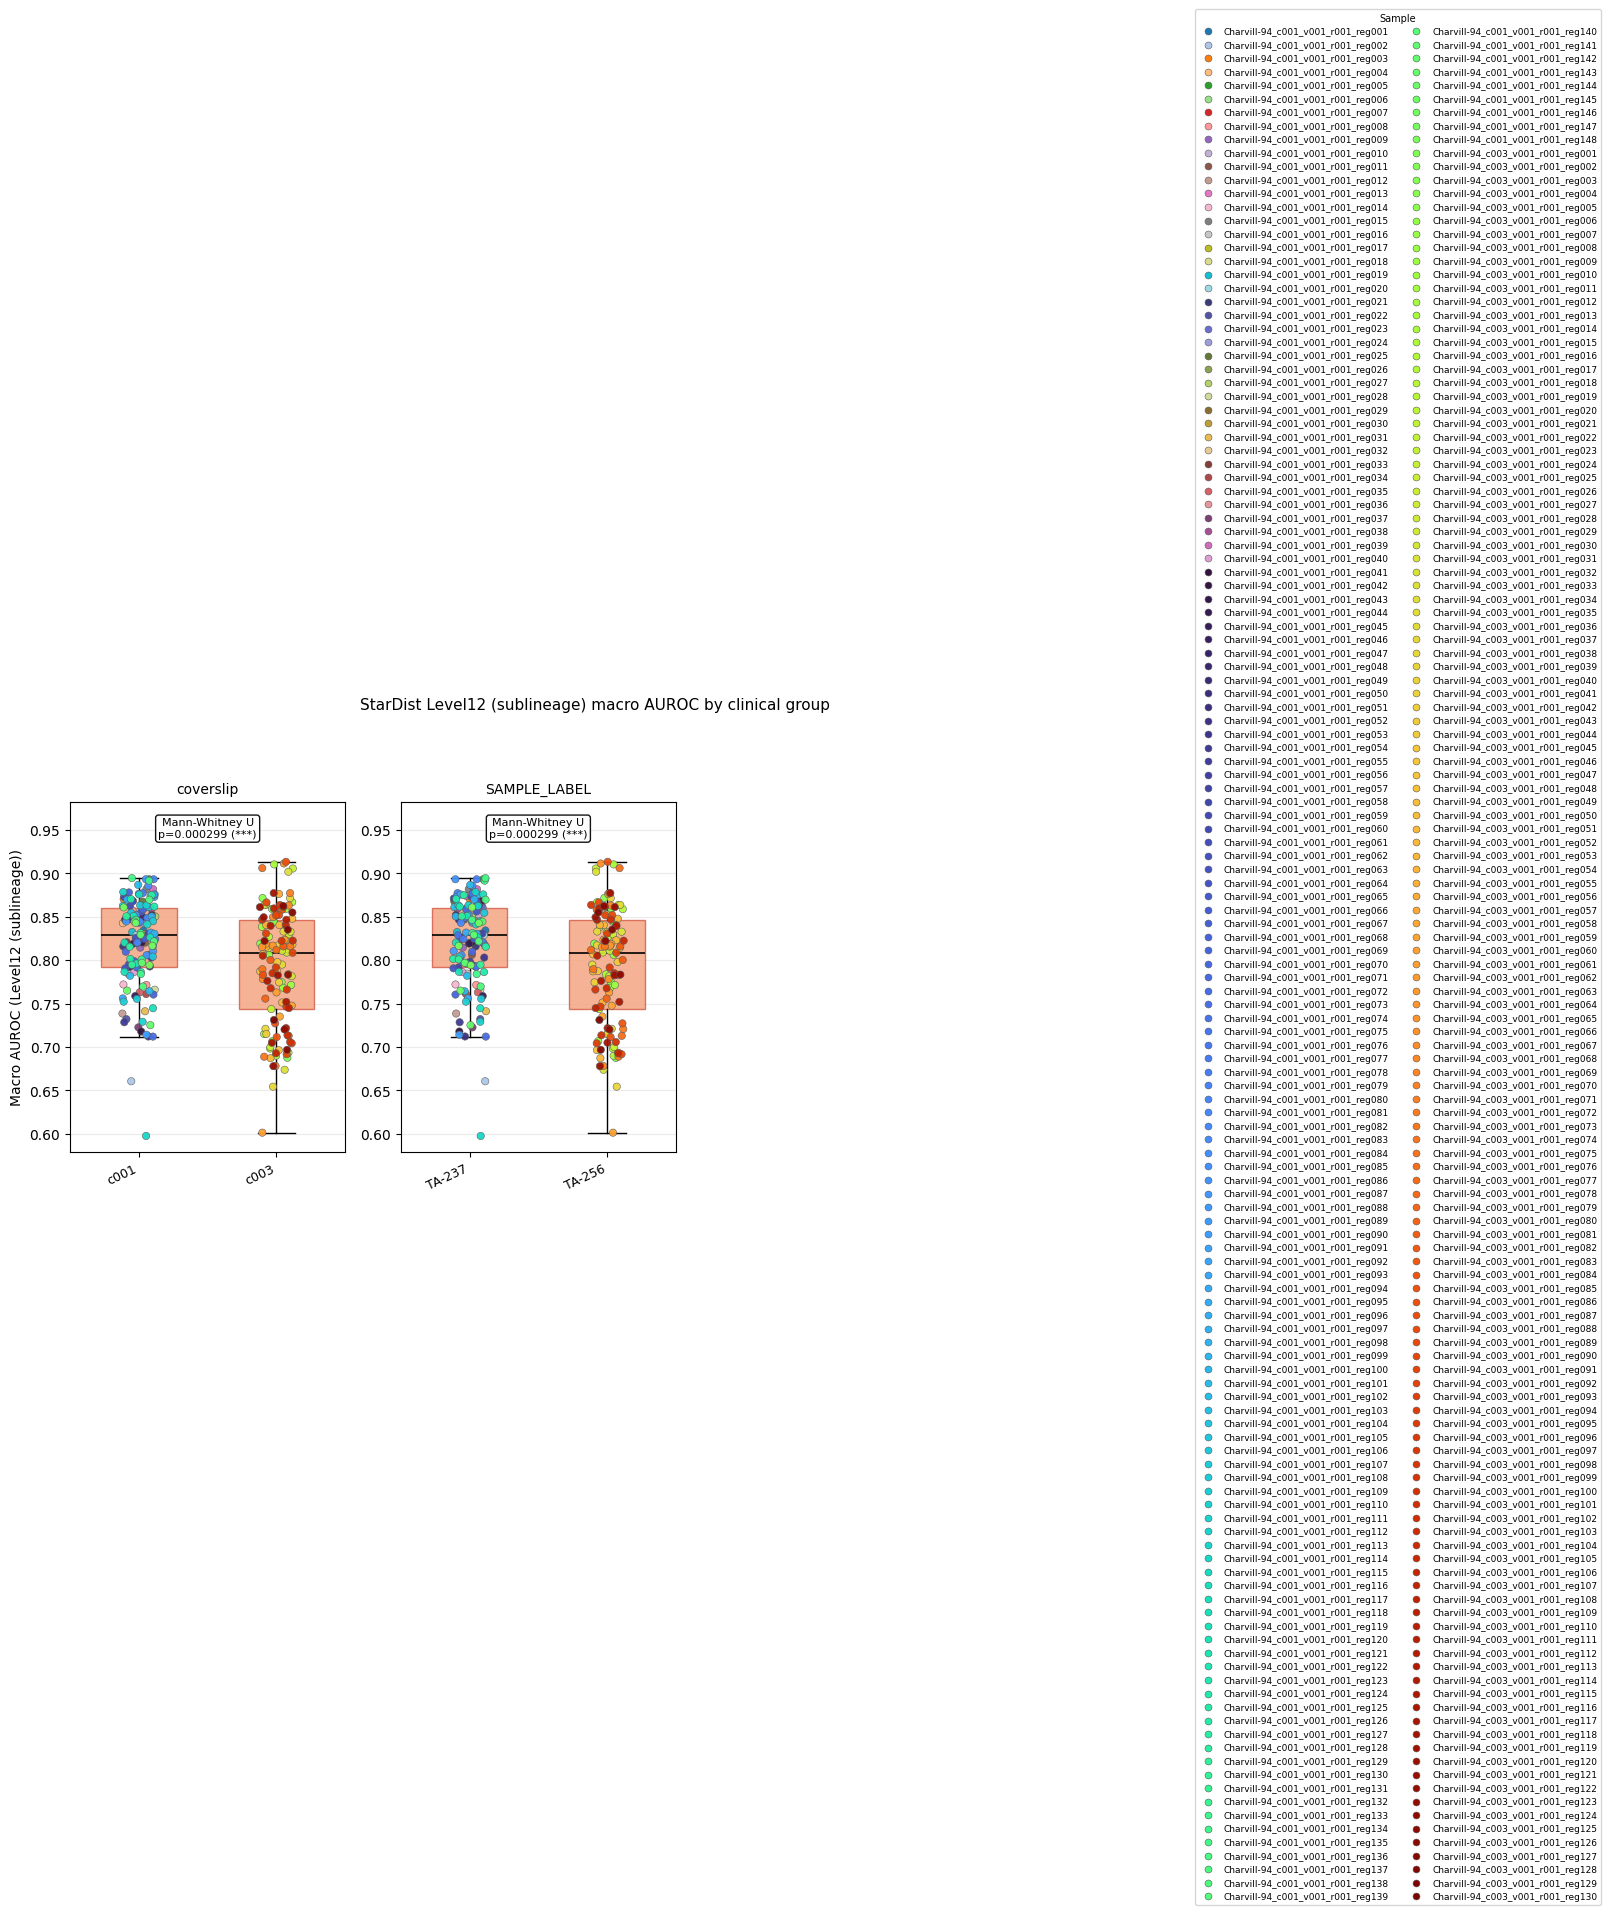


=== L1 macro AUROC vs clinical groups (method=rank) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,coverslip,macro_auc_l1,rank,Mann-Whitney U,5.896925e-07,12961.0,2,"[c001, c003]","[0.852366509310037, 0.8231925400712575]","[0.852366509310037, 0.8231925400712575]",6.229374
1,SAMPLE_LABEL,macro_auc_l1,rank,Mann-Whitney U,5.896925e-07,12961.0,2,"[TA-237, TA-256]","[0.852366509310037, 0.8231925400712575]","[0.852366509310037, 0.8231925400712575]",6.229374


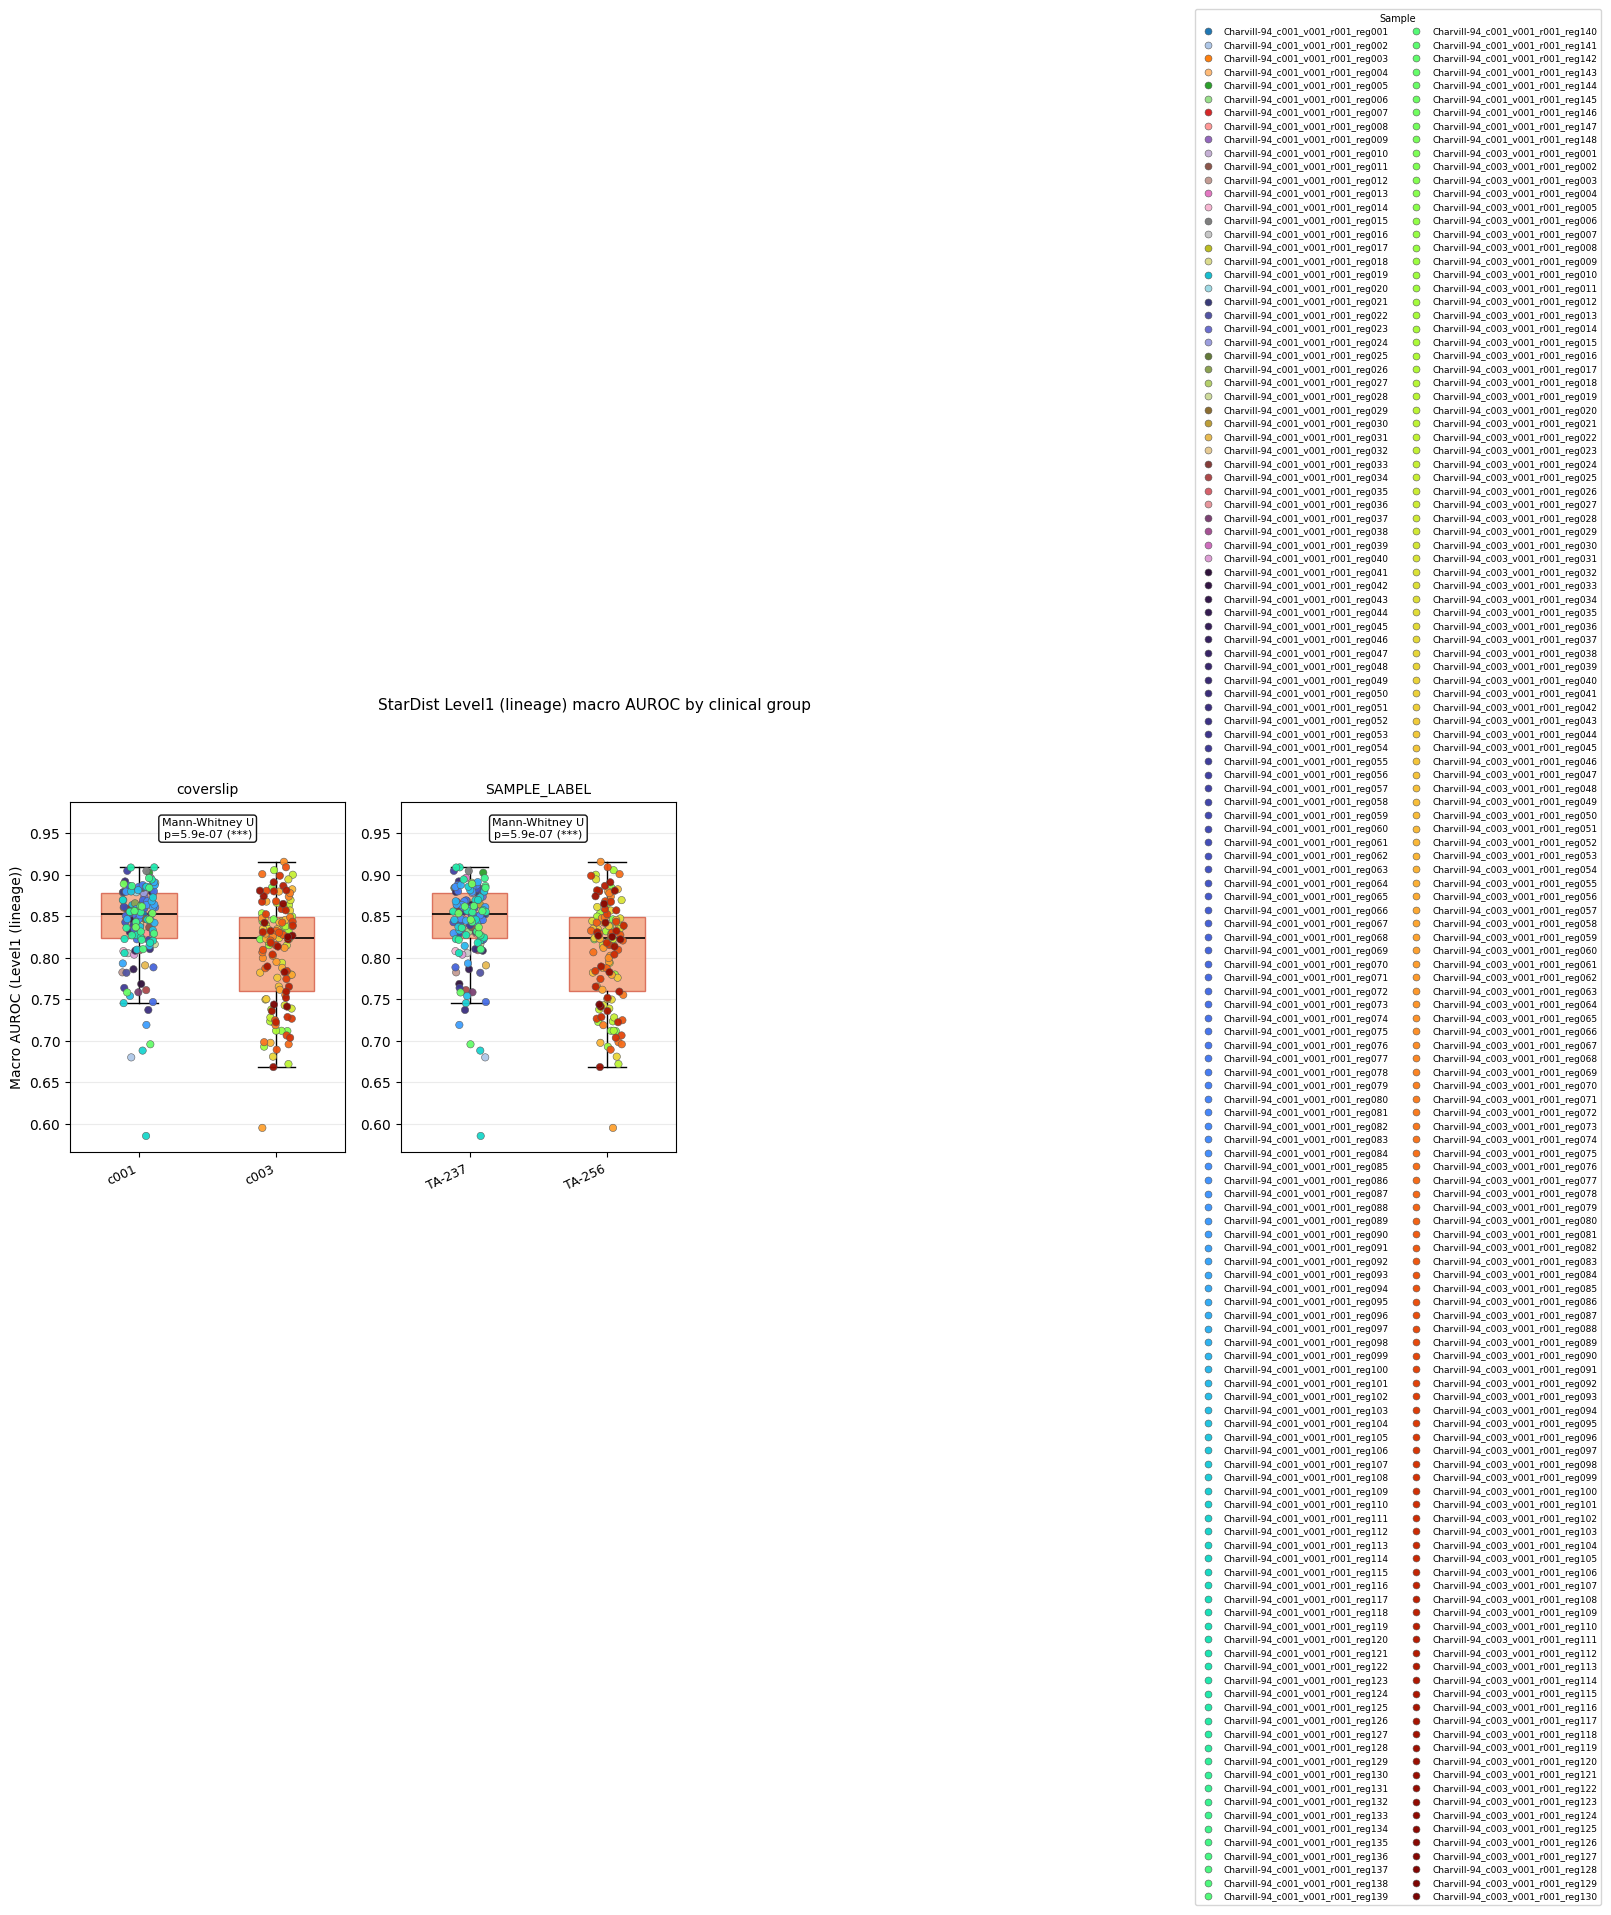

In [4]:
import importlib
import s1167_plot
importlib.reload(s1167_plot)
from s1167_plot import analyze_pdac_stardist_macro_auroc_by_clinical

stardist_auroc_clinical = analyze_pdac_stardist_macro_auroc_by_clinical(
    filtered_root,
    clinical,
    method="rank",
    pan_organ=PAN_ORGAN,
)
